### Import packages and define paths

In [155]:
from pathlib import Path
import json
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import random
import matplotlib.pyplot as plt
import numpy as np

In [140]:
# Define project and data paths
PROJECT_ROOT = Path("/Users/tildeidunsloth/Desktop/Thesis")
DATA_DIR = PROJECT_ROOT / "data/cleaned"

sci_fi_data_path = DATA_DIR / "sci_fi_stories_cleaned.jsonl"
romance_data_path = DATA_DIR / "romance_stories_cleaned.jsonl"
literary_fiction_data_path = DATA_DIR / "lit_fiction_stories_cleaned.jsonl"

### Load data and model

In [141]:
model = SentenceTransformer("all-MiniLM-L6-v2")
tokenizer = model.tokenizer

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1859.10it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [142]:
random.seed(42)  # for reproducibility

In [143]:
def load_jsonl_data(file_path):
    with open(file_path, 'r') as f:
        stories = [json.loads(line) for line in f]
    return stories

In [144]:
lit_fiction_stories = load_jsonl_data(literary_fiction_data_path)
romance_stories = load_jsonl_data(romance_data_path)
sci_fi_stories = load_jsonl_data(sci_fi_data_path)

### Selecting random and similar prompt stories

In [145]:
# select 100 random stories
lit_fiction_stories_random = random.sample(lit_fiction_stories, 100)

# select 100 stories with event = "discovers something new" and context = "on vacation"
lit_fiction_stories_same_event_context = [story for story in lit_fiction_stories if story['event'] == "discovers something new" and story['context'] == "on vacation"][:18]

### Functions

In [146]:
def embed_story(text, model):
    sentences = text.split(". ")  # or better sentence splitter
    
    embeddings = model.encode(
        sentences,
        convert_to_numpy=True,
        batch_size=32
    )
    
    return np.mean(embeddings, axis=0)

In [147]:
# function for extracting story texts and embedding them
def extract_and_embed(stories, model):
    story_texts = [item["story"] for item in stories]
    embeddings = [embed_story(text, model) for text in story_texts]
    return embeddings

In [148]:
def compute_semantic_distance_matrix(embeddings):
    """
    Returns:
        distance_matrix (N x N)
        similarity_matrix (N x N)
    """
    
    sim_matrix = cosine_similarity(embeddings)
    distance_matrix = 1 - sim_matrix
    
    return distance_matrix, sim_matrix

In [ ]:
def mean_corpus_distance(distance_matrix):
    n = distance_matrix.shape[0]
    upper = distance_matrix[np.triu_indices(n, k=1)] # only take upper triangle (excluding diagonal)
    return np.mean(upper)

### Results

In [150]:
embeddings_lit_fic_random = extract_and_embed(lit_fiction_stories_random, model)
distance_matrix, sim_matrix = compute_semantic_distance_matrix(embeddings_lit_fic_random)
mean_distance_random = mean_corpus_distance(distance_matrix)
print(f"Mean semantic distance (random): {mean_distance_random:.4f}")

Mean semantic distance (random): 0.2193


In [152]:
embeddings_lit_fic_same_event_context = extract_and_embed(lit_fiction_stories_same_event_context, model)
distance_matrix, sim_matrix = compute_semantic_distance_matrix(embeddings_lit_fic_same_event_context)
mean_distance_same_event_context = mean_corpus_distance(distance_matrix)
print(f"Mean semantic distance (same event context): {mean_distance_same_event_context:.4f}")

Mean semantic distance (same event context): 0.2173


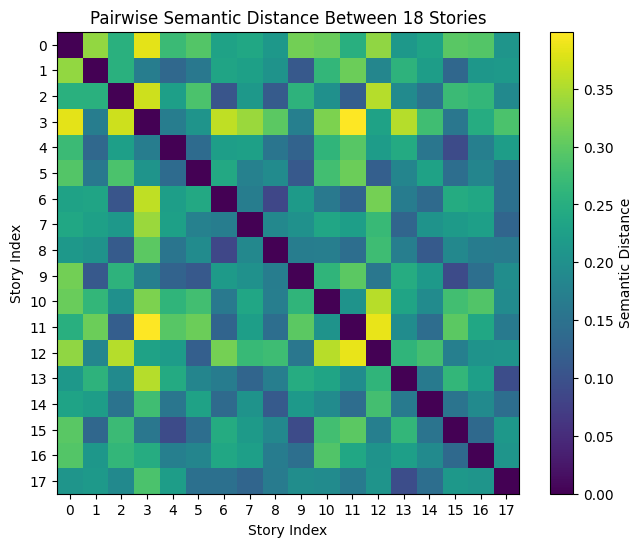

In [156]:
plt.figure(figsize=(8, 6))
im = plt.imshow(distance_matrix, cmap="viridis")  # or "coolwarm", "plasma", etc.

plt.colorbar(im, label="Semantic Distance")
plt.title("Pairwise Semantic Distance Between 18 Stories")
plt.xlabel("Story Index")
plt.ylabel("Story Index")
plt.xticks(ticks=np.arange(18))
plt.yticks(ticks=np.arange(18))
plt.show()